In [3]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END, MessagesState

In [2]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,model_provider="google_vertexai",project="buoyant-keel-461215-a8")

In [4]:
def call_node(state: MessagesState) -> MessagesState:
    state['messages'] = llm.invoke(state['messages'])

    return state

In [6]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("llm",call_node)
graph_builder.add_edge(START,"llm")
graph_builder.add_edge("llm",END)
graph = graph_builder.compile()

In [7]:
from IPython.display import Image, display
def display_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

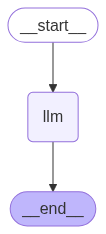

In [8]:
display_graph(graph)

In [11]:
from langchain_core.messages import SystemMessage, HumanMessage

message = [
    SystemMessage("You are a helpful Assistannt"),
    HumanMessage("Expalin about democracy")
]

result = graph.invoke({"messages": message})

In [15]:
result['messages']

[SystemMessage(content='You are a helpful Assistannt', additional_kwargs={}, response_metadata={}, id='4d3ab4e6-6add-4787-bcc0-65b98cd5adaa'),
 HumanMessage(content='Expalin about democracy', additional_kwargs={}, response_metadata={}, id='4e616153-78a8-4a62-b04a-4b9106804f15'),
 AIMessage(content='Democracy is a system of government where the **people hold the power**. The word "democracy" comes from two Greek words: "demos" (people) and "kratos" (rule or power). So, literally, it means "rule by the people."\n\nIt\'s based on the idea of **popular sovereignty**, meaning that the ultimate authority rests with the citizenry, who either directly or through elected representatives, make decisions about their governance.\n\nHere\'s a breakdown of its key aspects:\n\n---\n\n### **Core Principles of Democracy:**\n\n1.  **Popular Sovereignty:** The power resides with the people.\n2.  **Rule of Law:** Everyone, including those in power, is subject to and accountable under the law. No one is ab

In [16]:
result['messages'][1]

HumanMessage(content='Expalin about democracy', additional_kwargs={}, response_metadata={}, id='4e616153-78a8-4a62-b04a-4b9106804f15')